In [1]:
import os
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import sys

import glob
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys# less gpu heavy loss, SAM doesnt look good 
import glob

from torch.utils.data import Dataset
from typing import Optional, Callable, List, Dict, Tuple, Any
from tqdm import tqdm
import json
import wandb
from torchvision.utils import make_grid

torch.cuda.empty_cache()

In [ ]:
! export CODE_PATH="/media/ana-caznok/SSD-08/recon-segment"
! export DATA_PATH="/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"

In [ ]:
# Set visible CUDA devices
#os.environ["CUDA_VISIBLE_DEVICES"] = config["gpus"]
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/transforms")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/configs")

In [3]:
from fixed_dataset import FixedDataset
from seg_recon_vit3d import SegRecon_ViT_3D
from transforms.factory import transform_factory
from utils.read_yaml import read_yaml
from utils.model_select import model_select
from loss import loss_select

/home/ana-caznok/software/src/miniforge3/envs/agrvai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
config_path = "/media/ana-caznok/SSD-08/recon-segment/configs/"
config_name = 'test.yaml'
config_file = config_name

In [5]:
config = read_yaml(config_path + config_name)

In [6]:
# --------------------- CONFIG ---------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"
PREPROCESSING = config['preprocessing']  # or None or "downsampled"
BATCH_SIZE = 1#config['train']['batch_size']
NUM_EPOCHS = 2#config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
TRANSFORM = 'rgb2hyp_normal' #config['train']['transform_index']
MODEL_NAME = config['model']

In [7]:
# ------------------ DATASET + LOADER ------------------
train_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),  # You can define transforms here
    preprocessing=PREPROCESSING
)

val_dataset = FixedDataset(
    mode="val",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),
    preprocessing=PREPROCESSING
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading from hdf files
Number of face masks 234. 

Checking face mask integrity...: 234it [00:00, 1552954.33it/s]


initialized 234 images train DatasetRaw with preprocessing: h5py in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2 with transform RGB2Pseudo_Hyp with: /media/ana-caznok/SSD-08/recon-segment/ and camera norm. Fold: None
Loading from hdf files
Number of face masks 30. 

Checking face mask integrity...: 30it [00:00, 710898.98it/s]

initialized 30 images val DatasetRaw with preprocessing: h5py in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2 with transform RGB2Pseudo_Hyp with: /media/ana-caznok/SSD-08/recon-segment/ and camera norm. Fold: None


torch.Size([31, 1024, 1024])
torch.Size([61, 1024, 1024])


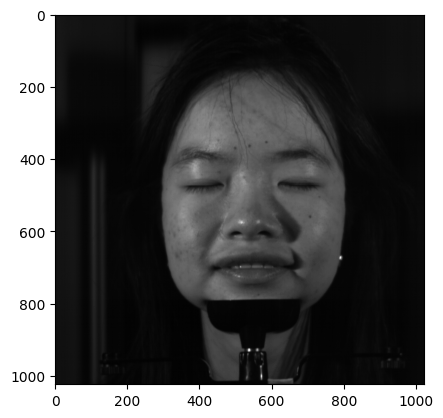

In [8]:
# ------------------ TESTING TRANSFORM ------------------
x, y, m = train_dataset[45]
print(x.shape)
print(y.shape)
x = x.cpu().numpy()
plt.imshow(x[21],cmap='gray')
plt.show()

In [ ]:
# ------------------ TESTING MULTIPLE TRANSFORMS ------------------

BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"
PREPROCESSING = config['preprocessing']  # or None or "downsampled"
BATCH_SIZE = config['train']['batch_size']
NUM_EPOCHS = config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
MODEL_NAME = config['model']

testing_transforms = ['donws4_fft_D40_cube_gpu_shift', 'downs4_fft_D40_cube_gpu', 
                      'donws4_fft_normal_cube_gpu_shift', 'downs4_fft_normal_cube_gpu',
                      'downs4_fft_double_D40_cube_gpu', 'downs4_fft_double_D40_cube_gpu_shift', 
                      'downs4_fft_double_normal_cube_gpu', 'downs4_fft_double_normal_cube_gpu_shift', 
                      'downs4_fft_double_normal_cube_gpu_shift_continuous', 
                      'downs4_fft_double-softmax_normal_cube_gpu_shift']

x_transf_dict = {'full_img': {}, 
                 'spectre': {}}
y_transf_dict = {'full_img': {}, 
                 'spectre': {}}


for t in testing_transforms: 
    TRANSFORM = t

    train_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),  # You can define transforms here
    preprocessing=PREPROCESSING
    )
    
    x, y, m = train_dataset[45]
    x = x.cpu().numpy()
    y = y.cpu().numpy()

    x_transf_dict['full_img'][t] = x
    y_transf_dict['full_img'][t] = y

    x_transf_dict['spectre'][t] = x[:,128,128]
    y_transf_dict['spectre'][t] = y[:,128,128]


    torch.cuda.empty_cache()

In [ ]:
import matplotlib.pyplot as plt

def plot_transform_comparisons(x_transf_dict):
    """
    Plots comparisons of different spectral transforms using the 'spectre' data
    from x_transf_dict. Each comparison highlights:
    - D40 vs Normal reflectance type
    - Shifted vs Non-shifted FFT
    - Double (real+imag) vs Single (magnitude-only) spectral representation
    """

    spectre_data = x_transf_dict['spectre']

    # Mapping for readable titles
    titles = {
        'donws4_fft_D40_cube_gpu_shift': 'D40, Shifted FFT, Magnitude',
        'downs4_fft_D40_cube_gpu': 'D40, Non-shifted FFT, Magnitude',
        'donws4_fft_normal_cube_gpu_shift': 'Normal, Shifted FFT, Magnitude',
        'downs4_fft_normal_cube_gpu': 'Normal, Non-shifted FFT, Magnitude',
        'downs4_fft_double_D40_cube_gpu': 'D40, Non-shifted FFT, Real+Imag',
        'downs4_fft_double_D40_cube_gpu_shift': 'D40, Shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_gpu': 'Normal, Non-shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_gpu_shift': 'Normal, Shifted FFT, Real+Imag'
    }

    # === D40 vs Normal (same FFT settings) ===
    d40_vs_normal_pairs = [
        ('donws4_fft_D40_cube_gpu_shift', 'donws4_fft_normal_cube_gpu_shift'),
        ('downs4_fft_D40_cube_gpu', 'downs4_fft_normal_cube_gpu'),
        ('downs4_fft_double_D40_cube_gpu', 'downs4_fft_double_normal_cube_gpu'),
        ('downs4_fft_double_D40_cube_gpu_shift', 'downs4_fft_double_normal_cube_gpu_shift')
    ]

    plt.figure(figsize=(14, 10))
    for i, (d40, norm) in enumerate(d40_vs_normal_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[d40], label='D40')
        plt.plot(spectre_data[norm], label='Normal')
        plt.title(f"Reflectance Comparison\n({titles[d40].split(',')[1].strip()}, {titles[d40].split(',')[2].strip()})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    plt.suptitle("D40 vs Normal Reflectance", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # === Shifted vs Non-Shifted (same reflectance and norm) ===
    shift_vs_noshift_pairs = [
        ('donws4_fft_D40_cube_gpu_shift', 'downs4_fft_D40_cube_gpu'),
        ('donws4_fft_normal_cube_gpu_shift', 'downs4_fft_normal_cube_gpu'),
        ('downs4_fft_double_D40_cube_gpu_shift', 'downs4_fft_double_D40_cube_gpu'),
        ('downs4_fft_double_normal_cube_gpu_shift', 'downs4_fft_double_normal_cube_gpu')
    ]

    plt.figure(figsize=(14, 10))
    for i, (shifted, noshift) in enumerate(shift_vs_noshift_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[shifted], label='Shifted FFT')
        plt.plot(spectre_data[noshift], label='Non-Shifted FFT')
        reflectance = titles[shifted].split(',')[0]
        norm_type = titles[shifted].split(',')[2].strip()
        plt.title(f"FFT Shift Comparison\n({reflectance}, {norm_type})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    plt.suptitle("Shifted vs Non-Shifted FFT", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # === Real+Imag vs Magnitude (same reflectance and shift) ===
    double_vs_single_pairs = [
        ('downs4_fft_double_D40_cube_gpu', 'downs4_fft_D40_cube_gpu'),
        ('downs4_fft_double_D40_cube_gpu_shift', 'donws4_fft_D40_cube_gpu_shift'),
        ('downs4_fft_double_normal_cube_gpu', 'downs4_fft_normal_cube_gpu'),
        ('downs4_fft_double_normal_cube_gpu_shift', 'donws4_fft_normal_cube_gpu_shift')
    ]

    plt.figure(figsize=(14, 10))
    for i, (double, single) in enumerate(double_vs_single_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[double], label='Real+Imag (Double)')
        plt.plot(spectre_data[single], label='Magnitude (Single)')
        reflectance = titles[double].split(',')[0]
        shift_status = titles[double].split(',')[1].strip()
        plt.title(f"Spectral Representation\n({reflectance}, {shift_status})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    plt.suptitle("Real+Imag vs Magnitude Representation", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    alternate_pair = ('downs4_fft_double_normal_cube_gpu_shift', 'downs4_fft_double_normal_cube_gpu_shift_continuous')
    plt.plot(spectre_data[alternate_pair[0]], label='Alternate')
    plt.plot(spectre_data[alternate_pair[1]], label='Continuous')
    plt.legend()
    plt.title(f"Spectral Representation of Stacking)")
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

    alternate_pair = ('downs4_fft_double_normal_cube_gpu_shift', 'downs4_fft_double-softmax_normal_cube_gpu_shift')
    plt.plot(spectre_data[alternate_pair[0]], label='MinMax')
    plt.plot(spectre_data[alternate_pair[1]], label='Softmax')
    plt.legend()
    plt.title(f"Spectral Representation of Normalization)")
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


In [ ]:
x_transf_dict['spectre'].keys()

In [ ]:
plot_transform_comparisons(x_transf_dict)

In [ ]:
plot_transform_comparisons(y_transf_dict)

In [ ]:
y = y.cpu().numpy()
signal = y[:,30,300]
plt.plot(signal)
plt.show()
transf_signal = fft(signal)
shift = fftshift(transf_signal)

In [ ]:
shift.imag

In [ ]:
plt.plot(transf_signal.real)
plt.show()

plt.plot(shift.real)
plt.show()

In [ ]:
dataloader_debug = iter(train_loader)
x, y, m = next(dataloader_debug)

plt.imshow(make_grid(x[:, :3]).permute(1, 2, 0),cmap='gray')
plt.show()

for batch in tqdm(train_loader):
    pass

In [9]:
# ------------------ MODEL ------------------
model = model_select(config).to(DEVICE)
criterion = loss_select(config)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Selected model seg-rec_31to61: SegRecon_ViT_3D
Selecting loss: MSE


In [ ]:
model.out_conv

In [ ]:
resume_file = None

In [10]:
def config2wandb(config):
    config_wandb = {} 
    for k in config: 
        if (k == 'train') or (k=='valid'): 
            for l in config[k]:
                config_wandb[k+'_'+l] = config[k][l]
        else: 
            config_wandb[k] = config[k]
    return config_wandb

In [11]:
from torchmetrics.image import StructuralSimilarityIndexMeasure
from metrics.sam import SAMScore

In [18]:
#del model
ssim_function = StructuralSimilarityIndexMeasure()#.to('cpu')
sam_function = SAMScore()#.to(DEVICE)
ssim = ssim_function(output.cpu(),y.cpu())
sam = sam_function(output.cpu(),y.cpu())

In [21]:
ssim_function.to('cpu')

StructuralSimilarityIndexMeasure()

In [20]:
sam

tensor(0.9119, grad_fn=<MeanBackward0>)

In [12]:
trn_history = []
val_history = []

# ------------------ INITIALIZING WANDB ------------------
name = os.path.basename(config_file).replace(".yaml", '')
name = 'metrics_tes2'
config['wandb'] = False
if config['wandb']: 
    run = wandb.init(project="SegRecViT",
                                reinit=True,
                                config = config2wandb(config), 
                                entity= 'rainbow-ai', 
                                notes="Running experiment",
                                name=name)


from torchmetrics.image import StructuralSimilarityIndexMeasure
from metrics.sam import SAMScore
# ------------------ TRAIN LOOP ------------------
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for x, y, meta in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    avg_train_loss = train_loss / len(train_loader)
    trn_history.append(avg_train_loss)

    if config['wandb']:
        wandb.log({f"Train Loss {config['loss']}": avg_train_loss})
        wandb.log({"epoch": epoch})

    # ------------------ EVAL LOOP ------------------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y, meta in tqdm(val_loader, desc="Validation"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            output = model(x)
            loss = criterion(output, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_history.append(avg_val_loss)
    ssim = StructuralSimilarityIndexMeasure(output,y)
    sam = SAMScore(output,y)

    if config['wandb']:
        wandb.log({f"Validation Loss {config['loss']}": avg_val_loss})
        wandb.log({"epoch": epoch})
        wandb.log({"SSIM": ssim})
        wandb.log({"SAM": sam})

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss == np.array(val_history).min(): 
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved to {SAVE_PATH}")
    
    if epoch%10 ==0: 
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved to {SAVE_PATH}")


# ------------------ SAVE MODEL ------------------
torch.save(model.state_dict(), SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

Epoch 1/2 - Training:   4%|▍         | 9/234 [00:17<07:07,  1.90s/it]


KeyboardInterrupt: 

In [ ]:
model(x)

In [ ]:
output.size()